Loaded: (240498, 7)
Date range: 2000-01-03 00:00:00 → 2021-04-30 00:00:00
Tickers: 50
Sample:
        date      ticker   open     high    low  close      volume
0 2007-11-27  ADANIPORTS  770.0  1050.00  770.0  962.9  27294366.0
1 2007-11-28  ADANIPORTS  984.0   990.00  874.0  893.9   4581338.0
2 2007-11-29  ADANIPORTS  909.0   914.75  841.0  884.2   5124121.0

Adding indicators to all 50 stocks...
Features shape: (230548, 35)
Date range: 2000-10-19 00:00:00 → 2021-04-30 00:00:00
Target distribution:
target
1    116343
0    114205
Name: count, dtype: int64

Train size: (213948, 20)
Test  size: (16600, 20)

=== Model Performance ===
Accuracy: 50.40%

Classification Report:
              precision    recall  f1-score   support

        DOWN       0.49      0.38      0.43      8094
          UP       0.51      0.62      0.56      8506

    accuracy                           0.50     16600
   macro avg       0.50      0.50      0.49     16600
weighted avg       0.50      0.50      0.50     

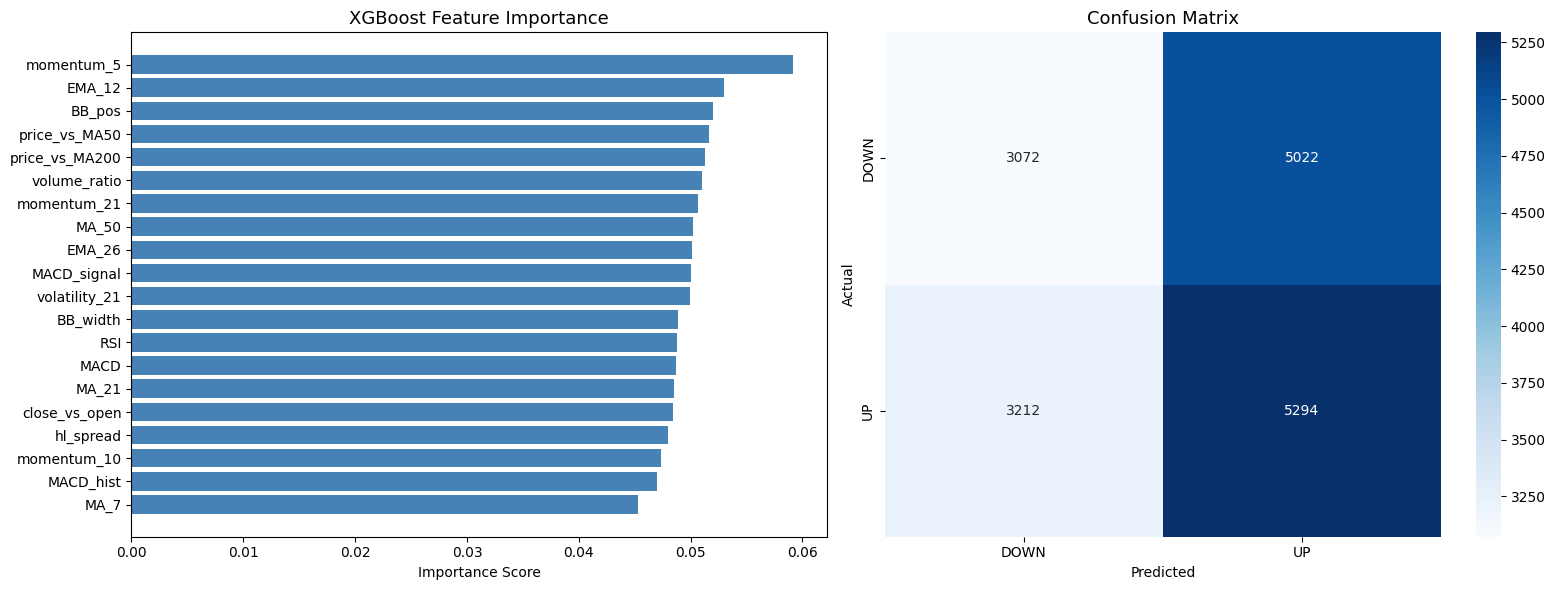

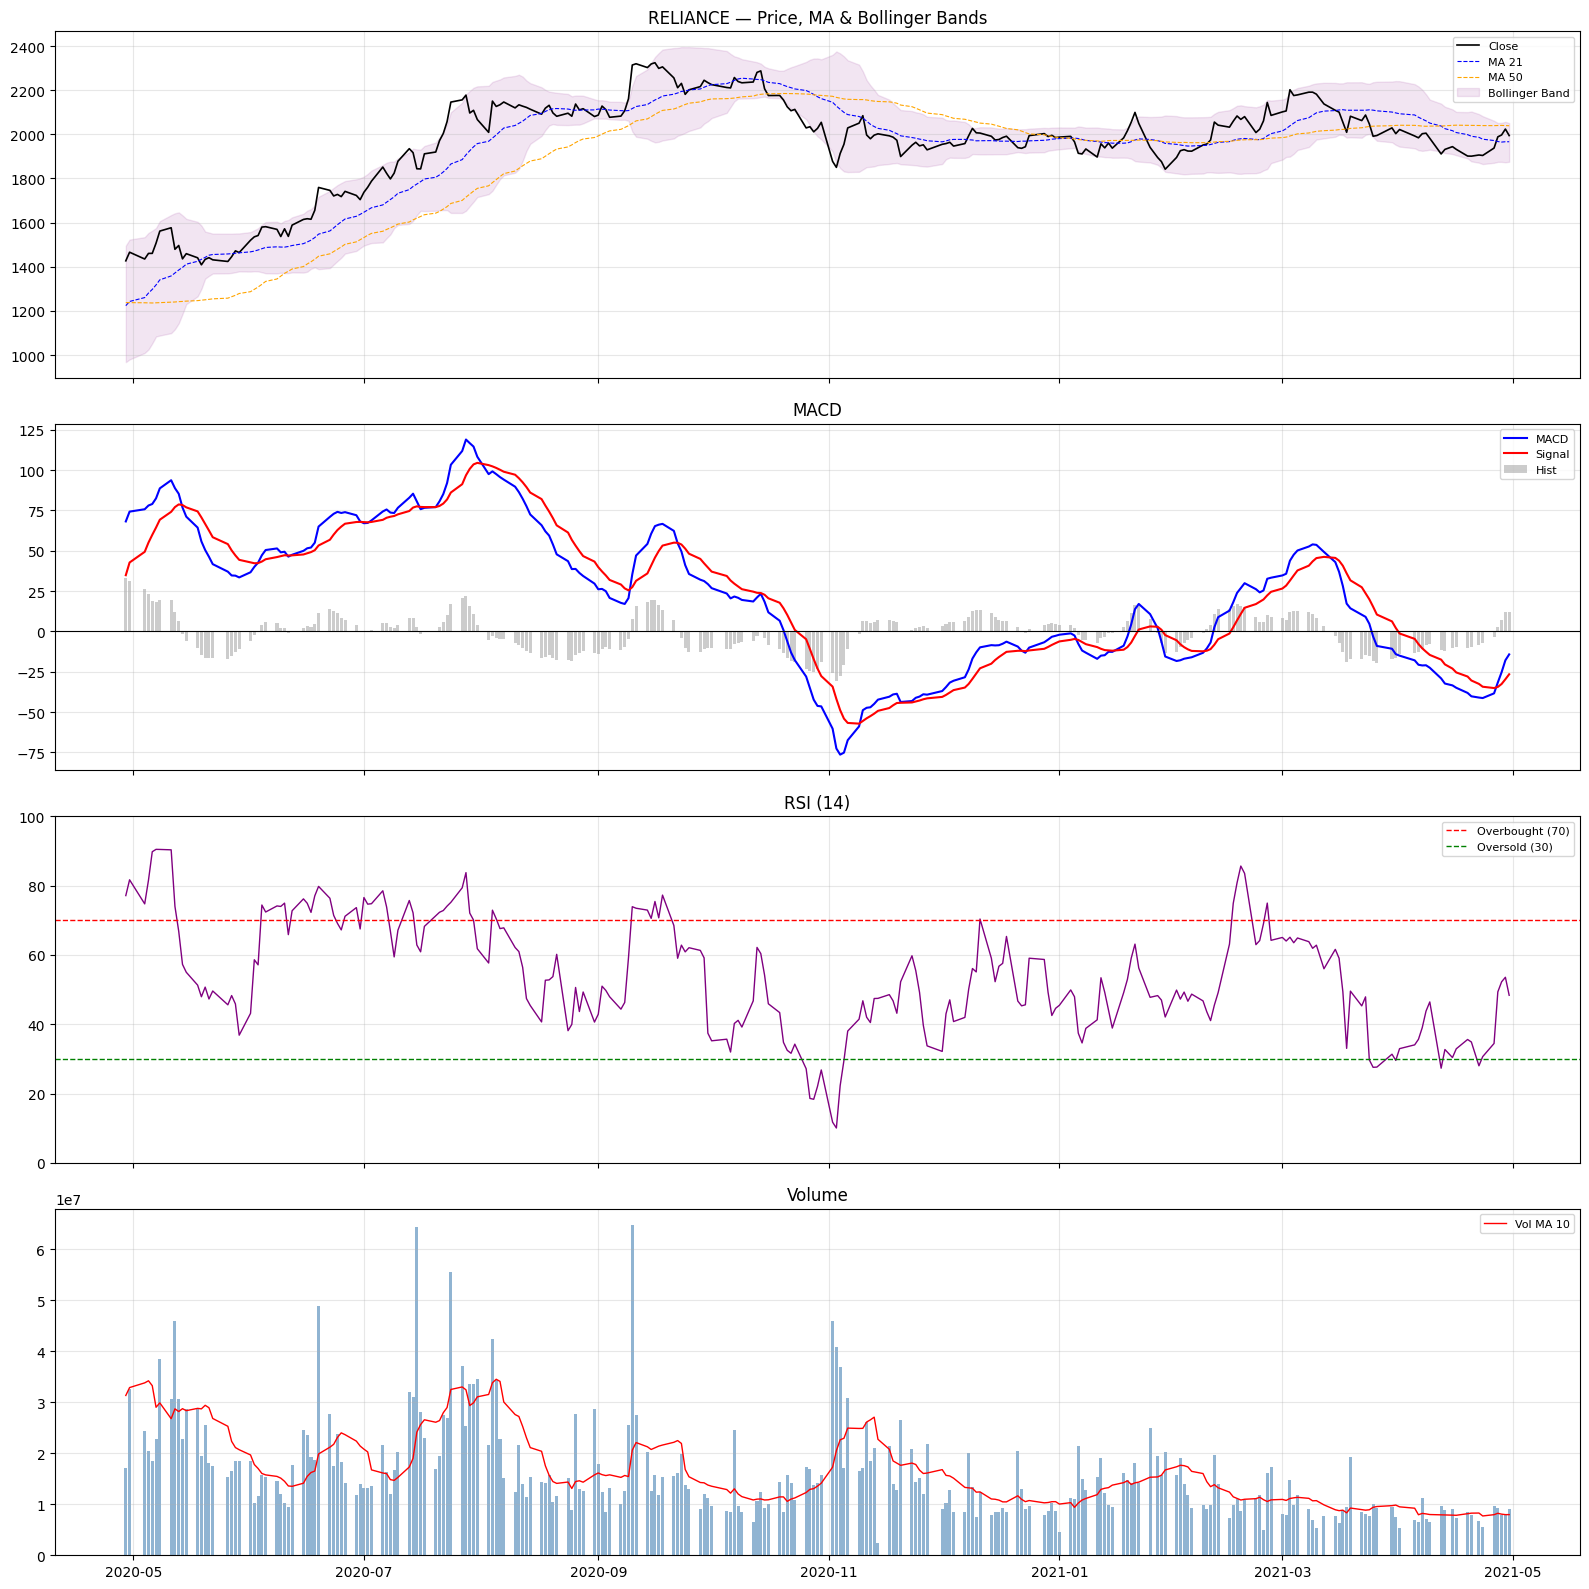


Features saved ✅ → C:\Users\sarin\Downloads\nifty50_project\data\features_data.csv
ALL DONE ✅


In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb
import joblib
import os
import warnings
warnings.filterwarnings('ignore')

DATA_PATH     = r"C:\Users\sarin\Downloads\nifty50_project\data\cleaned_data.csv"
MODEL_FOLDER  = r"C:\Users\sarin\Downloads\nifty50_project\models"
OUTPUT_FOLDER = r"C:\Users\sarin\Downloads\nifty50_project\outputs"
os.makedirs(MODEL_FOLDER, exist_ok=True)
os.makedirs(OUTPUT_FOLDER, exist_ok=True)

# ── LOAD ──────────────────────────────────────────────────────
df = pd.read_csv(DATA_PATH)
df['date'] = pd.to_datetime(df['date'], errors='coerce')
df = df.dropna(subset=['date'])

# Keep only essential columns — drop anything extra
df = df[['date','ticker','open','high','low','close','volume']].copy()

# Force numeric
for col in ['open','high','low','close','volume']:
    df[col] = pd.to_numeric(df[col], errors='coerce')

# Drop rows where close or volume is missing
df = df.dropna(subset=['open','high','low','close','volume'])
df = df.sort_values(['ticker','date']).reset_index(drop=True)

print(f"Loaded: {df.shape}")
print(f"Date range: {df['date'].min()} → {df['date'].max()}")
print(f"Tickers: {df['ticker'].nunique()}")
print(f"Sample:\n{df.head(3)}")

# ── TECHNICAL INDICATORS ──────────────────────────────────────
def add_technical_indicators(stock_df):
    d = stock_df.copy().reset_index(drop=True)

    # Moving Averages
    d['MA_7']   = d['close'].rolling(7).mean()
    d['MA_21']  = d['close'].rolling(21).mean()
    d['MA_50']  = d['close'].rolling(50).mean()
    d['MA_200'] = d['close'].rolling(200).mean()

    # EMA
    d['EMA_12'] = d['close'].ewm(span=12, adjust=False).mean()
    d['EMA_26'] = d['close'].ewm(span=26, adjust=False).mean()

    # MACD
    d['MACD']        = d['EMA_12'] - d['EMA_26']
    d['MACD_signal'] = d['MACD'].ewm(span=9, adjust=False).mean()
    d['MACD_hist']   = d['MACD'] - d['MACD_signal']

    # RSI
    delta    = d['close'].diff()
    gain     = delta.clip(lower=0)
    loss     = -delta.clip(upper=0)
    avg_gain = gain.rolling(14).mean()
    avg_loss = loss.rolling(14).mean()
    rs       = avg_gain / (avg_loss + 1e-10)
    d['RSI'] = 100 - (100 / (1 + rs))

    # Bollinger Bands
    d['BB_mid']   = d['close'].rolling(20).mean()
    d['BB_std']   = d['close'].rolling(20).std()
    d['BB_upper'] = d['BB_mid'] + 2 * d['BB_std']
    d['BB_lower'] = d['BB_mid'] - 2 * d['BB_std']
    d['BB_width'] = (d['BB_upper'] - d['BB_lower']) / (d['BB_mid'] + 1e-10)
    d['BB_pos']   = (d['close'] - d['BB_lower']) / (d['BB_upper'] - d['BB_lower'] + 1e-10)

    # Momentum
    d['momentum_5']  = d['close'].pct_change(5)
    d['momentum_10'] = d['close'].pct_change(10)
    d['momentum_21'] = d['close'].pct_change(21)

    # Volatility
    d['volatility_21'] = d['close'].pct_change().rolling(21).std()

    # Volume
    d['volume_MA_10'] = d['volume'].rolling(10).mean()
    d['volume_ratio'] = d['volume'] / (d['volume_MA_10'] + 1e-10)

    # Price features
    d['daily_return']   = d['close'].pct_change()
    d['hl_spread']      = (d['high'] - d['low']) / (d['close'] + 1e-10)
    d['close_vs_open']  = (d['close'] - d['open']) / (d['open'] + 1e-10)
    d['price_vs_MA50']  = (d['close'] - d['MA_50'])  / (d['MA_50']  + 1e-10)
    d['price_vs_MA200'] = (d['close'] - d['MA_200']) / (d['MA_200'] + 1e-10)

    # Target
    d['target'] = (d['close'].shift(-1) > d['close']).astype(int)

    return d

print("\nAdding indicators to all 50 stocks...")
all_stocks = []
for t in df['ticker'].unique():
    stock = df[df['ticker'] == t].copy()
    stock = add_technical_indicators(stock)
    all_stocks.append(stock)

df_features = pd.concat(all_stocks, ignore_index=True)

# Drop only rows where FEATURE columns have NaN (not all columns)
FEATURES = [
    'MA_7','MA_21','MA_50','EMA_12','EMA_26',
    'MACD','MACD_signal','MACD_hist',
    'RSI','BB_width','BB_pos',
    'momentum_5','momentum_10','momentum_21',
    'volatility_21','volume_ratio',
    'hl_spread','close_vs_open',
    'price_vs_MA50','price_vs_MA200'
]

df_features = df_features.dropna(subset=FEATURES + ['target'])
df_features['date'] = pd.to_datetime(df_features['date'])

print(f"Features shape: {df_features.shape}")
print(f"Date range: {df_features['date'].min()} → {df_features['date'].max()}")
print(f"Target distribution:\n{df_features['target'].value_counts()}")

# ── TRAIN / TEST SPLIT ────────────────────────────────────────
train_df = df_features[df_features['date'] < '2020-01-01']
test_df  = df_features[df_features['date'] >= '2020-01-01']
X_train  = train_df[FEATURES]
y_train  = train_df['target']
X_test   = test_df[FEATURES]
y_test   = test_df['target']

print(f"\nTrain size: {X_train.shape}")
print(f"Test  size: {X_test.shape}")

# ── TRAIN XGBOOST ─────────────────────────────────────────────
model = xgb.XGBClassifier(
    n_estimators=200,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='logloss',
    random_state=42
)
model.fit(X_train, y_train, eval_set=[(X_test, y_test)], verbose=False)
y_pred = model.predict(X_test)

print("\n=== Model Performance ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred)*100:.2f}%")
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['DOWN','UP']))

joblib.dump(model, os.path.join(MODEL_FOLDER, 'xgb_predictor.pkl'))
print("\nModel saved ✅")

# ── PLOTS ─────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

importance_df = pd.DataFrame({
    'feature'   : FEATURES,
    'importance': model.feature_importances_
}).sort_values('importance', ascending=True)
axes[0].barh(importance_df['feature'], importance_df['importance'], color='steelblue')
axes[0].set_title('XGBoost Feature Importance', fontsize=13)
axes[0].set_xlabel('Importance Score')

cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[1],
            xticklabels=['DOWN','UP'], yticklabels=['DOWN','UP'])
axes[1].set_title('Confusion Matrix', fontsize=13)
axes[1].set_xlabel('Predicted')
axes[1].set_ylabel('Actual')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'model_evaluation.png'), dpi=150)
plt.show()

# ── INDICATOR CHART ───────────────────────────────────────────
plot_ticker = 'RELIANCE'
if plot_ticker not in df_features['ticker'].unique():
    plot_ticker = df_features['ticker'].unique()[0]
sample = df_features[df_features['ticker'] == plot_ticker].tail(252).copy()

fig, axes = plt.subplots(4, 1, figsize=(16, 16), sharex=True)
axes[0].plot(sample['date'], sample['close'],   label='Close',  color='black',  linewidth=1.2)
axes[0].plot(sample['date'], sample['MA_21'],   label='MA 21',  color='blue',   linewidth=0.8, linestyle='--')
axes[0].plot(sample['date'], sample['MA_50'],   label='MA 50',  color='orange', linewidth=0.8, linestyle='--')
axes[0].fill_between(sample['date'], sample['BB_lower'], sample['BB_upper'],
                     alpha=0.1, color='purple', label='Bollinger Band')
axes[0].set_title(f'{plot_ticker} — Price, MA & Bollinger Bands')
axes[0].legend(fontsize=8); axes[0].grid(True, alpha=0.3)

axes[1].plot(sample['date'], sample['MACD'],        label='MACD',   color='blue')
axes[1].plot(sample['date'], sample['MACD_signal'], label='Signal', color='red')
axes[1].bar(sample['date'],  sample['MACD_hist'],   label='Hist',   color='gray', alpha=0.4)
axes[1].axhline(0, color='black', linewidth=0.8)
axes[1].set_title('MACD'); axes[1].legend(fontsize=8); axes[1].grid(True, alpha=0.3)

axes[2].plot(sample['date'], sample['RSI'], color='purple', linewidth=1)
axes[2].axhline(70, color='red',   linestyle='--', linewidth=1, label='Overbought (70)')
axes[2].axhline(30, color='green', linestyle='--', linewidth=1, label='Oversold (30)')
axes[2].set_ylim(0, 100)
axes[2].set_title('RSI (14)'); axes[2].legend(fontsize=8); axes[2].grid(True, alpha=0.3)

axes[3].bar(sample['date'], sample['volume'], color='steelblue', alpha=0.6)
axes[3].plot(sample['date'], sample['volume_MA_10'], color='red', linewidth=1, label='Vol MA 10')
axes[3].set_title('Volume'); axes[3].legend(fontsize=8); axes[3].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, 'technical_indicators.png'), dpi=150)
plt.show()

# ── SAVE FEATURES ─────────────────────────────────────────────
FEATURES_PATH = r"C:\Users\sarin\Downloads\nifty50_project\data\features_data.csv"
df_features.to_csv(FEATURES_PATH, index=False)
print(f"\nFeatures saved ✅ → {FEATURES_PATH}")
print("ALL DONE ✅")